<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" style="width: 30%;">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Deslocamentos transversais de vigas

### Problema 5

## Deslocamentos transversais de vigas

A figura representa a viga ABC à qual está rigidamente ligada uma barra BD. A viga suporta uma carga distribuída trapezoidal $Q(x)$ aplicada entre B e C e duas cargas concentradas, F e P aplicadas em D. Sabendo que $Q_B =$ 25 kN/m, $Q_C =$ 75 kN/m, $F =$ 20 kN, $P = $ 40 kN e $L =$ 6 m determine:

**a)** As reações nos apoios e a equação da linha elástica.

**b)** Trace os diagramas do esforço transverso e do momento fletor entre A e C.

**c)** Obtenha o valor da flecha máxima na viga.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au09/P5/MSII_Au09_P5.png"
style="width: 50%;"/>



In [ ]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '1'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

def printsymSF(expr):
    expr2 = sy.simplify(sy.factor(expr))
    return expr2.xreplace({n : round(n, 3) for n in expr2.atoms(sy.Number)})

# data structure, units: N, mm, MPa

class varin: pass

d = varin()

d.L = 6.  # unit: m
d.QB = 25 # unit: kN
d.QC = 75 # unit: kN
d.F = 20 # unit: kN
d.P = 40 # unit: kN
d.AB = 2 # unit: m
d.BC = 4 # unit: m
def printsymSF(expr):
    expr2 = sy.simplify(sy.factor(expr))
    return expr2.xreplace({n : round(n, 3) for n in expr.atoms(sy.Number)})

### a) As reações nos apoios e a equação da linha elástica.

### Resolução

- 1 ::: sistema força-binário equivalente

\begin{equation*}
F_{x_B} = F
\quad\wedge\quad
M_B = -F\left(\frac{L}{6}\right)
\quad\wedge\quad
F_{y_B} = P
\end{equation*}

In [ ]:
print(f':: sistema força-binário equivalente ::')
FxB = d.F
print(f'FxB = {FxB:.1f} [kN]')

MB = d.F*d.L/6
print(f'MB = {MB:.1f} [kN.m]')

FyB = d.P
print(f'FyB = {FyB:.1f} [kN]')

:: sistema força-binário equivalente ::
FxB = 20.0 [kN]
MB = 20.0 [kN.m]
FyB = 40.0 [kN]


- 2 ::: Carga distribuida

A carga distribuida $Q_x$ é constituida por duas partes, a distribuição triangular e a distribuição retangular.

- Carga distribuida triangular

\begin{equation*}
Q(x) = m x
\quad\wedge\quad
m = \frac{Q_C-Q_B}{(2/3)L}
\end{equation*}

tendo como carga resultante equivalente e linha de acção sobre o centroide da área,

\begin{equation*}
Q_{eq} = \int_0^L \frac{Q_C-Q_B}{2L/3} x~\mathrm{d}x
\quad\wedge\quad
\overline{x} = \frac{2}{3}  \overline{BC}
\end{equation*}








- Carga distribuida retangular

\begin{equation*}
Q(x) = Q_b
\end{equation*}

tendo como carga resultante equivalente e linha de acção sobre o centroide da área,

\begin{equation*}
Q_{eq} = \int_0^L Q_c \, x~\mathrm{d}x
\quad\wedge\quad
\overline{x} = \frac{1}{2} \overline{BC}
\end{equation*}

In [ ]:
print("::: Carga distribuida quadrangular :::")
x = sy.symbols('x')

def qtri(x): return ((d.QC-d.QB)/d.BC)*x
d.k = (d.QC-d.QB)/d.BC
print(f'Q(x) = {printsymSF(qtri(x))} [kN]')

qtri_eq = sy.integrate(qtri(x),(x,0,d.BC))
print(f'qtri_eq = {qtri_eq:.1f} [kN]')
qtri_xcent =2 + 2/3*d.BC
print(f'qtri_xcent (por formulário) = {qtri_xcent:.2f} [m]')
iiaux = sy.integrate(qtri(x)*x,(x,0,d.BC))


::: Carga distribuida quadrangular :::
Q(x) = 12.5*x [kN]
qtri_eq = 100.0 [kN]
qtri_xcent (por formulário) = 4.67 [m]


In [ ]:
print("::: Carga distribuida quadrangular :::")

qquad_eq = d.QB*d.BC
print(f'qquad_eq = {qquad_eq} [kN]')
qquad_xcent =2 + 1/2*d.BC
print(f'qquad_xcent (por formulário) = {qquad_xcent:.2f} [m]')

::: Carga distribuida quadrangular :::
qquad_eq = 100 [kN]
qquad_xcent (por formulário) = 4.00 [m]


- 3 ::: cálculo das reações

\begin{equation*}
\sum F_x = 0
\quad\wedge\quad
\sum F_y = 0
\quad\wedge\quad
\sum M = 0
\end{equation*}

In [ ]:
rax, ray, ma, rcy = sy.symbols('rax ray ma rcy')

print('::: sistema de equações :::')
sumFX = rax - d.F
d.Qeq = qquad_eq + qtri_eq
print(f'd.Qeq = {d.Qeq:.1f} N')
sumFY = ray + rcy - d.P - d.Qeq
print(f'sumFY = {sumFY} N')
sumM = ma - MB -d.P*d.AB - qquad_eq*qquad_xcent - qtri_eq*qtri_xcent +d.L*rcy
print(f'sumM = {sumM} N.m')


::: sistema de equações :::
d.Qeq = 200.0 N
sumFY = ray + rcy - 240.0 N
sumM = ma + 6.0*rcy - 966.666666666667 N.m


### Problema indeterminado:
Desenhando o diagrama de corpo livre e escrevendo as equações de equilíbrio para este
problema pode concluir-se que existem 4 reações incógnitas para apenas 3 equações, pelo que se
trata de um problema indeterminado.

 ### Como resolver :

A resolução de um problema deste tipo pode ser conseguida adicionando equações
suplementares que estão associadas à deformação. Neste caso basta adicionar 1 equação.
Essa equação surge quando se consideram as condições fronteira sobre a equação da linha
elástica (ou sobre a equação da tangente à linha elástica, dy/dx).


É por isso necessário escrever a equação da linha elástica. Mas como não se conhecem as
reações, esta deverá ser escrita com as reações como incógnitas.

1. Para começar, escreve-se a
equação dos momentos:

\begin{equation*}
M(x) = R_{Ay} <x-0>^1 - M_{A} <x-0>^0 - P<x-2>^1 + M_{B} <x-2>^0 - \frac{Q_0}{2}<x-2>^2 - \frac{k}{(2)(3)}<x-2>^3 + \underbrace{R_{Cy} <x-L>^1}_{off}
\end{equation*}

2. Equação da linha elástica:

\begin{equation*}
\frac{\partial² v(x)}{\partial x²} = \frac{M(x)}{EI}
\end{equation*}

por integração, obtem-se

\begin{equation*}
\theta(x) = \frac{\partial v(x)}{\partial x} = \left[
\frac{R_{Ay}}{2} <x-0>^2 - M_{A} <x-0>^1 - \frac{P}{2}<x-2>^2
+ M_{B} <x-2>^1 - \frac{Q_0}{6}<x-2>^3 \frac{k}{(6)(4)}<x-2>^4 + C_1 \right] / EI
\end{equation*}

integrando novamente resulta

\begin{equation*}
v(x) = \left[
\frac{R_{Ay}}{6} <x-0>^3 - \frac{M_{Ay}}{2} <x-0>^2 - \frac{P}{6}<x-2>^3
- \frac{Q}{24}<x-2>^4 - \frac{k}{(24)(5)}<x-2>^5 + C_1x + C_2 \right] / EI
\end{equation*}

As constantes de integração $C_1$ e $C_2$ são determinadas pelas condições de fronteira.

\begin{equation*}
\begin{aligned}
x = 0 \quad\Rightarrow\quad y(0) = 0
&\quad\therefore\quad C_2 = 0
\end{aligned}
\end{equation*}

\begin{equation*}
\begin{aligned}
x = 0 \quad\Rightarrow\quad θ(0) = 0
&\quad\therefore\quad C_1 = 0
\end{aligned}
\end{equation*}

Ficamos então com:

\begin{equation*}
v(x) = \left[
\frac{R_{Ay}}{6} <x-0>^3 - \frac{M_{Ay}}{2} <x-0>^2 - \frac{P}{6}<x-2>^3
- \frac{Q}{24}<x-2>^4 - \frac{k}{24*5}<x-2>^5  \right] / EI
\end{equation*}

Fazendo o mesmo para o ponto $x = L$, tem-se:

\begin{equation*}
\begin{aligned}
x = L \quad\Rightarrow\quad y(L) = 0
\quad\Rightarrow\quad 0 = \frac{R_{Ay}}{6} <x-0>^3 - \frac{M_{Ay}}{2} <x-0>^2 - \frac{P}{6}<x-2>^3
- \frac{Q}{24}<x-2>^4 - \frac{k}{(24)(5)}<x-2>^5
\end{aligned}
\end{equation*}

\begin{equation*}
\begin{aligned}
\quad\Rightarrow\quad 640 = 36 R_{Ay} - 18 M_a
\quad\Rightarrow\quad M_a = -35.55 +2 R_{Ay}
\end{aligned}
\end{equation*}



In [ ]:
rax, ray, ma, rcy = sy.symbols('rax ray ma rcy')

print('::: sistema de equações :::')
sumFX = rax - d.F
d.Qeq = qquad_eq + qtri_eq
print(f'd.Qeq = {d.Qeq:.1f} N')
sumFY = ray + rcy - d.P - d.Qeq
print(f'sumFY = {sumFY} N')
sumM = ma - MB - d.P*d.AB - qquad_eq * qquad_xcent - qtri_eq * qtri_xcent + d.L*rcy
print(f'sumM = {sumM} N.m')
sumMb = -35.55 + 2*ray - ma
print(f'ma = {ma} N.m')
sol = solve([sumFX,sumFY,sumM,sumMb],[rax, ray, rcy, ma])

print('::: resolução :::')
RAx = sol[rax]; print(f'RAx = {RAx:.1f} N')
RAy = sol[ray]; print(f'RAy = {RAy:.1f} N')
RCy = sol[rcy]; print(f'RCy = {RCy:.1f} N')
Ma = sol[ma]; print(f'Ma = {Ma:.1f} N')

::: sistema de equações :::
d.Qeq = 200.0 N
sumFY = ray + rcy - 240.0 N
sumM = ma + 6.0*rcy - 966.666666666667 N.m
ma = ma N.m
::: resolução :::
RAx = 20.0 N
RAy = 109.4 N
RCy = 130.6 N
Ma = 183.3 N


###  b) Trace os diagramas do esforço transverso e do momento fletor entre A e C.

In [ ]:
VAB = RAy
VBC = RAy - d.P - d.QB*(x-2) - d.k/2*(x-2)**2

MAB = RAy*x - Ma
MBC = RAy*x - Ma - d.P*(x-2) + MB - d.QB/2*(x-2)**2 - d.k/6*(x-2)**3

xAB = np.linspace(0,d.AB)
xBC = np.linspace(d.AB,d.BC)

def sy2array(sygunc,xlist):
    scalar_func = lambda xx: float(sygunc.evalf(subs={x: xx}))
    vector_func = np.vectorize(scalar_func)
    return vector_func(xlist)

# AB
yVAB = sy2array(VAB,xAB)
yMAB = sy2array(MAB,xAB)

# BC
yVBC = sy2array(VBC,xBC)
yMBC = sy2array(MBC,xBC)

### Diagrama do esforço transverso

- Tramo AB:

\begin{equation*}
V(x) = R_{Ay} <x-0>^0
\end{equation*}

- Tramo BC:

\begin{equation*}
V(x) = R_{Ay} <x-0>^0 - P<x-2>^0 - {Q_0}<x-2>^1 - \frac{k}{2}<x-2>^2 + \underbrace{R_{Cy} <x-L>^0}_{off}
\end{equation*}



### Diagrama do momento fletor

- Tramo AB:

\begin{equation*}
M(x) = R_{Ay} <x-0>^1 - M_{A} <x-0>^0
\end{equation*}

- Tramo BC:

\begin{equation*}
M(x) = R_{Ay} <x-0>^1 - M_{A} <x-0>^0 - P<x-2>^1 + M_{B} <x-2>^0 - \frac{Q_0}{2}<x-2>^2 - \frac{k}{(2)(3)}<x-2>^3 + \underbrace{R_{Cy} <x-L>^1}_{off}
\end{equation*}

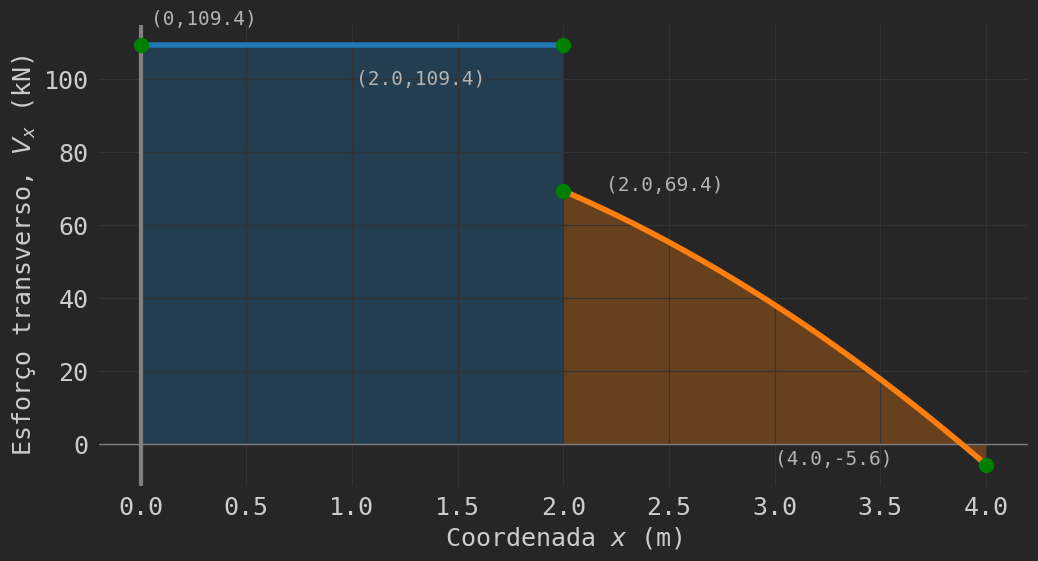

In [ ]:
fz = 14
fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=3,color=(.5, .5, .5))
plt.plot(xAB,yVAB,linewidth=4)
plt.fill_between(xAB, yVAB, alpha=.3)
plt.plot(xBC,yVBC,linewidth=4); plt.fill_between(xBC,yVBC, alpha=.3)
plt.xlabel('Coordenada $x$ (m)'); plt.ylabel('Esforço transverso, $V_{x}$ (kN)')
plt.plot(xAB[0],yVAB[0],'go',markersize=10)
plt.text(xAB[0]+.05,yVAB[0]*1.05,f'({xAB[0]:.0f},{yVAB[0]:.1f})',fontsize=fz)
plt.plot(xAB[-1],yVAB[-1],'go',markersize=10)
plt.text(xAB[-1]*.51,yVAB[-1]*.9,f'({xAB[-1]:.1f},{yVAB[-1]:.1f})',fontsize=fz)
plt.plot(xBC[0],yVBC[0],'go',markersize=10)
plt.text(xBC[0]*1.1,yVBC[0]*1.,f'({xBC[0]:.1f},{yVBC[0]:.1f})',fontsize=fz)
plt.plot(xBC[-1],yVBC[-1],'go',markersize=10)
plt.text(xBC[-1]*.75,yVBC[-1]*1.02,f'({xBC[-1]:.1f},{yVBC[-1]:.1f})',fontsize=fz)
ax.xaxis.set_ticks_position('none'); ax.yaxis.set_ticks_position('none')
plt.grid(True); plt.show()

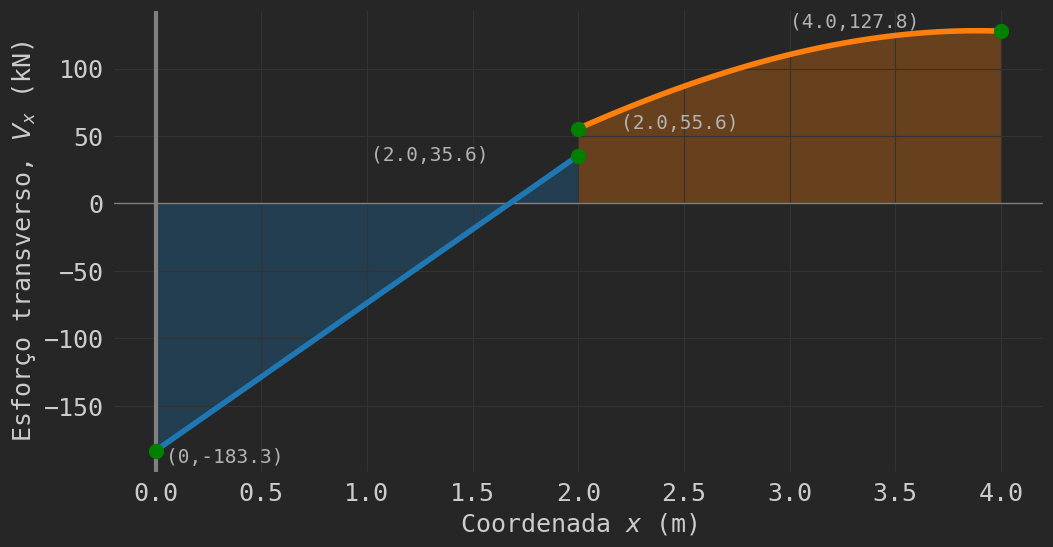

In [ ]:
fz = 14
fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=3,color=(.5, .5, .5))
plt.plot(xAB,yMAB,linewidth=4)
plt.fill_between(xAB, yMAB, alpha=.3)
plt.plot(xBC,yMBC,linewidth=4); plt.fill_between(xBC,yMBC, alpha=.3)
plt.xlabel('Coordenada $x$ (m)'); plt.ylabel('Esforço transverso, $V_{x}$ (kN)')
plt.plot(xAB[0],yMAB[0],'go',markersize=10)
plt.text(xAB[0]+.05,yMAB[0]*1.05,f'({xAB[0]:.0f},{yMAB[0]:.1f})',fontsize=fz)
plt.plot(xAB[-1],yMAB[-1],'go',markersize=10)
plt.text(xAB[-1]*.51,yMAB[-1]*.9,f'({xAB[-1]:.1f},{yMAB[-1]:.1f})',fontsize=fz)
plt.plot(xBC[0],yMBC[0],'go',markersize=10)
plt.text(xBC[0]*1.1,yMBC[0]*1.,f'({xBC[0]:.1f},{yMBC[0]:.1f})',fontsize=fz)
plt.plot(xBC[-1],yMBC[-1],'go',markersize=10)
plt.text(xBC[-1]*.75,yMBC[-1]*1.02,f'({xBC[-1]:.1f},{yMBC[-1]:.1f})',fontsize=fz)
ax.xaxis.set_ticks_position('none'); ax.yaxis.set_ticks_position('none')
plt.grid(True); plt.show()

c) Obtenha o valor da flecha máxima na viga.

- Flexa máxima

Para o ponto onde a flexa é máxima temos que :

\begin{equation*}
\theta(x) = 0
\end{equation*}

Fazendo então os calculos obtemos :

\begin{equation*}
\theta(x) = \left[\frac{R_{Ay}}{2} <x-0>^2 - M_{A} <x-0>^1 - \frac{P}{2}<x-2>^2
+ M_{B} <x-2>^1 - \frac{Q_0}{6}<x-2>^3 - \frac{k}{(6)(4)}<x-2>^4 \right] / EI
\end{equation*}

Daqui se retira os valores de $x$, obtendo:

\begin{equation*}
x = 3.52431
\quad\vee\quad
x = -0.64611
\quad\vee\quad
x = 7.62578
\quad\vee\quad
x = -10.50399
\end{equation*}

Como:

\begin{equation*}
x \quad \in \quad [0;6]
\end{equation*}

Tem-se que :
\begin{equation*}
x = 3.52
\end{equation*}

Então,

\begin{equation*}
v(x) = \left[
\frac{R_{Ay}}{6} <x-0>^3 - \frac{M_{Ay}}{2} <x-0>^2 - \frac{P}{6}<x-2>^3 + \frac{M_{By}}{2} <x-2>^2 - \frac{Q}{24}<x-2>^4 - \frac{k}{(24)(5)}<x-2>^5  \right] / EI
\end{equation*}

\begin{equation*}
v(x) = \left[
\frac{109.4}{6} <3.52-0>^3 - \frac{183.33}{2} <3.52-0>^2 + \frac{20}{2} <3.52-2>^2 - \frac{40}{6}<3.52-2>^3
- \frac{25}{24}<3.52-2>^4 - \frac{12.5}{(24)(5)}<3.52-2>^5  \right] / EI
\end{equation*}

\begin{equation*}
v(x) = -347,247 / EI
\end{equation*}

### Apêndice A: Equação da elástica

A equação $y(x)$ descreve a posição deformada do eixo da viga devido à ação do momento fletor. Esta equação é conhecida como a equação da linha elástica e pode ser obtida na prática através da solução de uma equação diferencial por dupla integração da equação do momento fletor ao longo da viga. A equação resultante deve ainda satisfazer as condições de fronteira do problema, ou seja, ser cinematicamente admissível. Esta condição permitirá determinar, nomeadamente, as constantes de integração resultantes do processo de integração.

A hipótese de Euler-Bernoulli para o problema de flexão de uma viga conduz à seguinte equação,

\begin{equation*}
\varepsilon_{xx} = -\frac{y}{\rho}
\end{equation*}

Assumindo ainda a lei de Hooke para o comportamento linear elástico do materia, $\sigma_{xx} = E \varepsilon_{xx}$, pode obter-se uma relação entre o momento flector $M(x)$ e o raio de curvatura da superfície neutra da viga $\rho$,

\begin{equation*}
\sigma_{xx} = E \varepsilon_{xx} =
-\frac{yE}{\rho}
\quad\wedge\quad
\sigma_{xx} = -\frac{My}{I_z}
\quad\therefore\quad
\frac{1}{\rho} = \frac{M}{EI_z}
\end{equation*}

Considerando agora a relação entre o raio de curvatura $\rho$ e as segundas derivadas da função $y(x)$, que para pequenos valroes resulta,

\begin{equation*}
\frac{1}{\rho} \approx \frac{\mathrm{d}² y}{\mathrm{d} x²}
\end{equation*}

obtém-se finalmente,

\begin{equation*}
\frac{\mathrm{d}² y}{\mathrm{d} x²}
= \frac{M}{EI_z}
\end{equation*}

Assim sendo, para se obter a equação da elástica da viga do problema, $y(x)$, é necessário:

1. Escrever a equação do momento fletor na viga, $M(x)$ - nomeadamente usando funções de singularidasde;

2. Integrar duas vezes essa equação;

3. Aplicar condições fronteira para calcular as duas constantes que surgem durante a integração.



### Apêndice B: Funções de singularidade

As expressões $⟨x − a⟩^0$, $⟨x − a⟩^1$, $⟨x − a⟩^2$ são designadas por funçoes singulares. Quando $n ≥ 0$,

\begin{equation*}
⟨x − a⟩^n =
\begin{cases}
(x − a)^n & \quad\text{se } x \ge a \\
0 & \quad\text{se } x < a \\
\end{cases}
\end{equation*}

Nota-se que, os parênteses angulares ⟨ ⟩ devem ser substituídos por parênteses curvos ( ) quando $x ≥ a$ e por zero quando $x < a$.

Segue da definição de funções singularidades que,

\begin{equation*}
\int ⟨x − a⟩^n \mathrm{d}x = \frac{1}{n+1}
⟨x − a⟩^{n+1} \quad\textrm{se}\quad n \ge 0
\end{equation*}

e

\begin{equation*}
\frac{d}{dx} ⟨x − a⟩^n = n⟨x − a⟩^{n-1} \quad\textrm{se}\quad n \ge 1
\end{equation*}

### Anexo: Funções de singularidade

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Formulario/singularity_functions.png"
width="900">

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a> (in collaboration with the student João Vasconcelos)

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>